In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Hittar projektmappen
project_folder = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

In [2]:
# Hittar projektmappen
project_folder = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

# Läser in dirty datasetet
df_dirty = pd.read_csv(project_folder / 'data' / 'dirty' / 'yrbs_dirty_9vars.csv')

# Väljer mina variabler
cols = ['row_id', 'weight_orig', 'mental_health_not_good', 'grade']
df_dirty = df_dirty[cols].copy()

# Visar första raderna
df_dirty.head()

,row_id,weight_orig,mental_health_not_good,grade
0,1,180,1.0,NaN
1,2,233,3.0,NaN
2,3,165,2.0,NaN
3,4,105,3.0,NaN
4,5,125,3.0,NaN


In [3]:
# Grundläggande info
print('INFO:')
df_dirty.info()

print('\nMISSING VALUES:')
print(df_dirty.isnull().sum())

print('\nDUBLETTER:')
print(df_dirty.duplicated().sum())

INFO:
<class 'pandas.DataFrame'>
RangeIndex: 20118 entries, 0 to 20117
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   row_id                  20118 non-null  int64
 1   weight_orig             19434 non-null  str  
 2   mental_health_not_good  15734 non-null  str  
 3   grade                   30 non-null     str  
dtypes: int64(1), str(3)
memory usage: 628.8 KB

MISSING VALUES:
row_id                        0
weight_orig                 684
mental_health_not_good     4384
grade                     20088
dtype: int64

DUBLETTER:
15


In [4]:
# Value counts (konstiga och saknade värden, text istället för siffror)
print('GRADE:')
print(df_dirty['grade'].value_counts(dropna=False))

print('\nMENTAL HEALTH:')
print(df_dirty['mental_health_not_good'].value_counts(dropna=False))

print('\nWEIGHT:')
print(df_dirty['weight_orig'].value_counts(dropna=False).head(30))

GRADE:
grade
NaN           20088
Grade 10         10
10th grade       10
2                10
Name: count, dtype: int64

MENTAL HEALTH:
mental_health_not_good
3.0        4744
NaN        4384
4.0        3376
2.0        3304
1.0        2837
5.0        1433
 always      10
A            10
5            10
Always       10
Name: count, dtype: int64

WEIGHT:
weight_orig
120    952
130    906
140    841
150    800
135    718
N      714
125    690
NaN    684
160    626
145    607
115    565
110    546
180    451
165    420
170    402
155    385
200    330
175    310
190    286
100    242
105    236
185    231
210    179
220    178
138    158
230    154
128    149
132    147
118    147
195    132
Name: count, dtype: int64


In [8]:
# Försöker göra om till siffror
weight_dirty = pd.to_numeric(df_dirty['weight_orig'], errors='coerce')
mental_dirty = pd.to_numeric(df_dirty['mental_health_not_good'], errors='coerce')
grade_dirty = pd.to_numeric(df_dirty['grade'], errors='coerce')

# Statistik
print(weight_dirty.describe())
print(mental_dirty.describe())
print(grade_dirty.describe())

count    18716.000000
mean       151.985253
std         46.710393
min          0.000000
25%        122.000000
50%        141.000000
75%        170.000000
max        999.000000
Name: weight_orig, dtype: float64
count    15704.000000
mean         2.827050
std          1.218901
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: mental_health_not_good, dtype: float64
count    10.0
mean      2.0
std       0.0
min       2.0
25%       2.0
50%       2.0
75%       2.0
max       2.0
Name: grade, dtype: float64


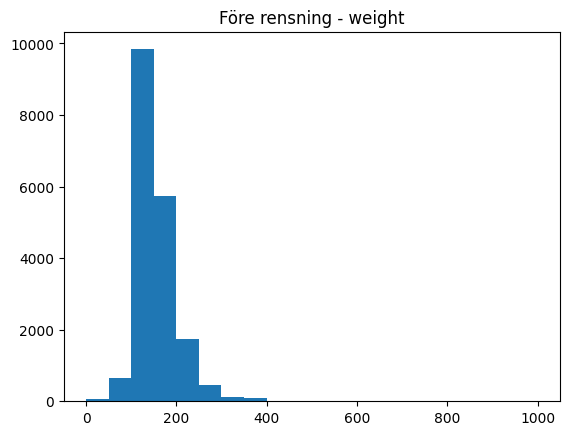

In [9]:
# Histogram
plt.hist(weight_dirty.dropna(), bins=20)
plt.title('Före rensning - weight')
plt.show()

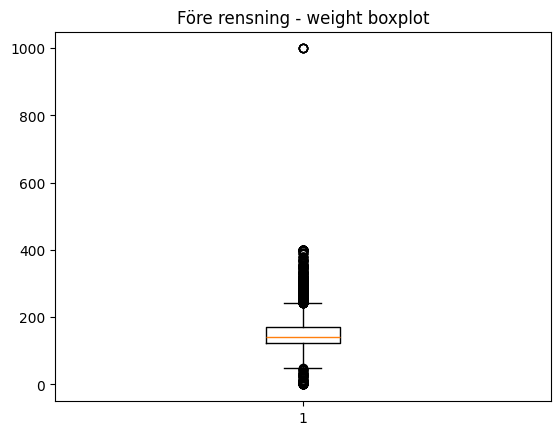

In [10]:
# Boxplot
plt.boxplot(weight_dirty.dropna())
plt.title('Före rensning - weight boxplot')
plt.show()

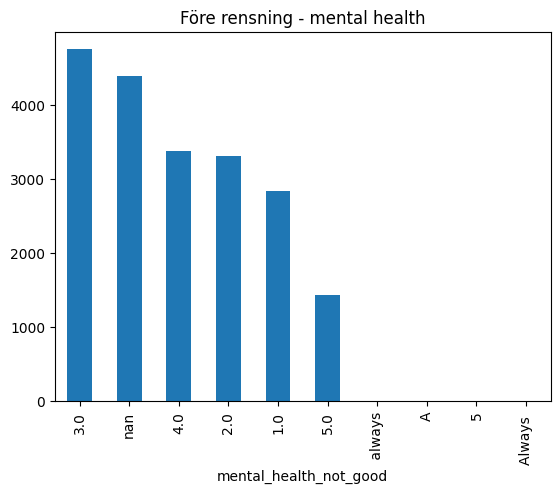

In [11]:
# Stapeldiagram
df_dirty['mental_health_not_good'].value_counts(dropna=False).plot(kind='bar')
plt.title('Före rensning - mental health')
plt.show()

I den initiala analysen ser vi att variablerna innehåller felaktiga datatyper, saknade värden och inkonsekventa format. Exempelvis innehåller weight_orig både numeriska värden och textvärden, medan grade till stor del saknar giltiga värden.

In [16]:
# Läs in cleaned data
df_clean = pd.read_csv(project_folder / 'data' / 'cleaned' / 'yrbs_emmy_cleaned.csv')

df_clean.head()

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\emmyk\\dev\\tdm\\week2-cleaning-dataset-yrbs\\data\\cleaned\\yrbs_emmy_cleaned.csv'